# SVG to Fourier Epicycles Notebook

Load an SVG drawing, sample it into points, compute Fourier components, reconstruct the curve, and animate epicycles as a GIF.

Use this notebook with `test_svg.svg` (or your own exported SVG) to compare original vs reconstruction and tune animation quality/speed.


## Sampling the SVG


Load an SVG, sample points from all paths, normalize them, and plot.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from svgpathtools import svg2paths2

In [5]:
def sample_svg(svg_file, num_samples=2000):
    """Sample points from an SVG file."""

    paths, attributes, svg_attributes = svg2paths2(svg_file)

    if not paths:
        raise ValueError("No paths found in the SVG file.")

    #print(paths)

    #decide how many points (counts) to sample from each path based on its length
    lengths = [path.length() for path in paths]
    total_length = sum(lengths)
    counts = [max(2, int(num_samples * (length / total_length))) for length in lengths]

    #adjust counts so we have exactly num_samples points
    while sum(counts) > num_samples:
        i = int(np.argmax(counts))
        if counts[i] > 2:
            counts[i] -= 1 #deletes path with largest current count, but ensures at least 2 points per path
        else:
            break

    while sum(counts) < num_samples:
        i = int(np.argmax(lengths))
        counts[i] += 1

    #print(counts)

    points = []
    #sample points from each path according to counts
    for path, count in zip(paths, counts):
        ts = np.linspace(0, 1, count, endpoint=False)
        for t in ts:
            point = path.point(t) #returns complex number, x + yi
            # SVG's y-axis points downward, flip y for Cartesian
            points.append((point.real, -point.imag))

    #normalize points to fit in a unit square centered at the origin
    points = np.array(points, float)
    points -= points.mean(axis=0, keepdims=True) #center
    points /= np.max(np.linalg.norm(points, axis=1)) #scale
    return points

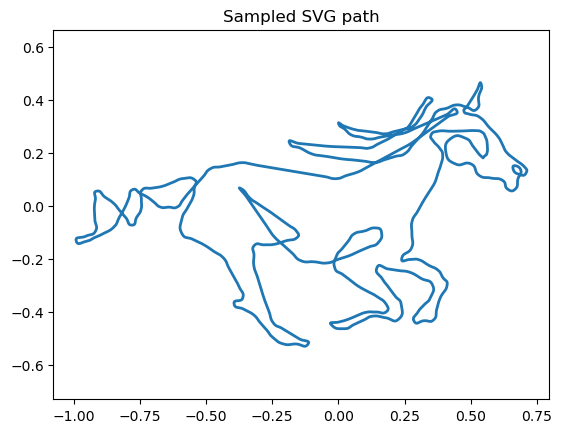

In [6]:
points = sample_svg('test_svg.svg', num_samples=2500)
plt.plot(points[:, 0], points[:, 1], linewidth=2)
plt.axis("equal")
plt.title("Sampled SVG path")
plt.show()

## Fouier Coefficients

Get k and c_k values, where c_k is complex coefficient and k is frequency

In [7]:
def fourier_components(points):
    """Compute Fourier components from sampled points.
    points: Nx2 array of (x, y) coordinates, centered and scaled
    returns: freqs (N,), coeffs (N,) complex Fourier coefficients
    z(t) = sum_k coeffs[k] * exp(2pi*i*freqs[k]*t)
    """
    z = points[:, 0] + 1j * points[:, 1] #convert to complex
    N = len(z)

    coeffs = np.fft.fft(z) / N #calculate DFT, normalize by N
    #cycles per d units, d is seconds/samples, so d=1/N, thus freqs are in cycles per sample
    freqs = np.fft.fftfreq(N, d=1.0/N).astype(int) #frequencies corresponding to coeff
    return freqs, coeffs

#### testing fourier_components function

In [15]:
N = 128
z = np.ones(N, dtype=complex) * (3 + 2j)
points = np.c_[z.real, z.imag]
freqs, coeffs = fourier_components(points)

coeffs
#should be just 3 + 2j at freq 0, and 0 for all other freqs

array([3.+2.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
      

## Reconstruct the curve

Reconstruction max abs error: 5.815852873680767e-16


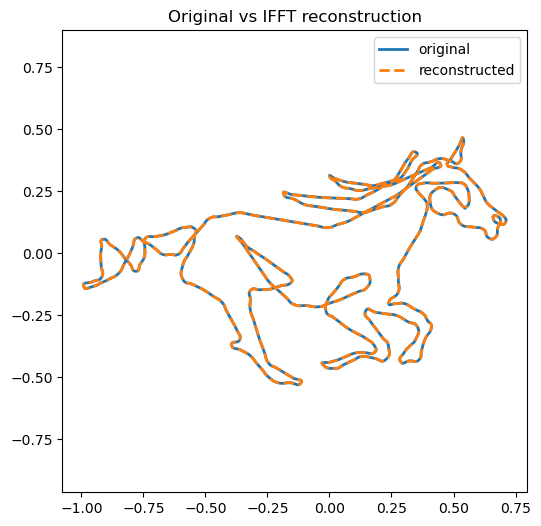

In [18]:
points = sample_svg('test_svg.svg', num_samples=2500)

freqs, coeffs = fourier_components(points)

#reconstruct z[n] using inverse FFT 
z = points[:, 0] + 1j * points[:, 1]
z_rec = np.fft.ifft(coeffs * len(z)) #coeffs = fft(z)/N

print("Reconstruction max abs error:", np.max(np.abs(z - z_rec)))

plt.figure(figsize=(6, 6))
plt.plot(z.real, z.imag, label="original", linewidth=2)
plt.plot(z_rec.real, z_rec.imag, "--", label="reconstructed", linewidth=2)
plt.axis("equal")
plt.legend()
plt.title("Original vs IFFT reconstruction")
plt.show()

#SHOULD OVERLAP!


## Animation

In [50]:
from matplotlib.animation import FuncAnimation, PillowWriter
from tqdm.auto import tqdm
from PIL import Image

In [51]:
def epicycle_chain(freqs, coeffs, t, order):
    """
    freqs, coeffs: full arrays from FFT
    t in [0,1)
    order: indices specifying which components (and in what order) to draw
    Returns complex chain points p0..pK (p0=0, pK=end)
    """
    p = 0 + 0j
    chain = [p] #start at origin
    for idx in order:
        k = freqs[idx]
        c = coeffs[idx]
        p = p + c * np.exp(1j * 2 * np.pi * k * t) #add contribution of this epicycle to the chain
        chain.append(p)
    return np.array(chain)


In [54]:
def animate_epicycles(points, freqs, coeffs, n_vectors=250, frames=None, gif_seconds=10, preview_interval_ms=20):
    """Animate epicycles drawing the path defined by points, using the Fourier components.
    n_vectors: how many epicycles (components) to draw, ordered by magnitude
    frames: number of sampled time steps (detail). If None, uses len(points)
    gif_seconds: target duration of exported GIF in seconds
    Note: GIF players often cap effective FPS; we enforce a duration cap for compatibility.
    returns: the FuncAnimation object
    """
    z = points[:, 0] + 1j * points[:, 1]
    N = len(z)

    mags = np.abs(coeffs) #size

    # we want to draw the largest-magnitude components (largest ck),which change final sum more
    # oick top-k by magnitude, draw them in DESCENDING magnitude order
    order = np.argsort(-mags)[:n_vectors]

    if frames is None:
        frames = len(points)
    max_viewer_fps = 50
    base_fps = frames / gif_seconds
    max_frames_for_cap = max(1, int(round(gif_seconds * max_viewer_fps)))
    if frames > max_frames_for_cap:
        frames = max_frames_for_cap
        base_fps = frames / gif_seconds
    save_fps = max(1, min(max_viewer_fps, int(round(base_fps))))
    ts = np.linspace(0, 1, frames, endpoint=False)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect("equal", "box")
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.axis("off")

    # artists: one vector per component
    vectors = []
    for _ in range(len(order)):
        vec, = ax.plot([], [], linewidth=2)
        vectors.append(vec)

    # artist for the trace of the final point
    trace_line, = ax.plot([], [], linewidth=2)
    trace = []

    def init():
        #initially empty artists
        for a in vectors:
            a.set_data([], [])
        trace_line.set_data([], [])
        return vectors + [trace_line]

    def update(i):
        t = ts[i]
        chain = epicycle_chain(freqs, coeffs, t, order)

        # draw vectors
        for j in range(len(order)):
            center = chain[j]
            tip = chain[j + 1]
            vectors[j].set_data([center.real, tip.real], [center.imag, tip.imag])

        end = chain[-1]
        trace.append(end)
        tr = np.array(trace)
        trace_line.set_data(tr.real, tr.imag)

        return vectors + [trace_line]

    anim = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True, interval=preview_interval_ms)
    pbar = tqdm(total=frames, desc="Saving epicycles.gif")
    anim.save(
        "epicycles.gif",
        writer=PillowWriter(fps=save_fps),
        progress_callback=lambda i, n: pbar.update(1)
    )
    pbar.close()
    # Enforce GIF duration metadata to be <= gif_seconds.
    with Image.open("epicycles.gif") as im:
        n = getattr(im, "n_frames", 1)
        duration_ms = max(20, int((gif_seconds * 1000) // max(1, n)))
        gif_frames = []
        for i in range(n):
            im.seek(i)
            gif_frames.append(im.copy())
    gif_frames[0].save(
        "epicycles.gif",
        save_all=True,
        append_images=gif_frames[1:],
        duration=duration_ms,
        loop=0,
        disposal=2
    )
    plt.show()
    return anim

Saving epicycles.gif:   0%|          | 0/400 [00:00<?, ?it/s]

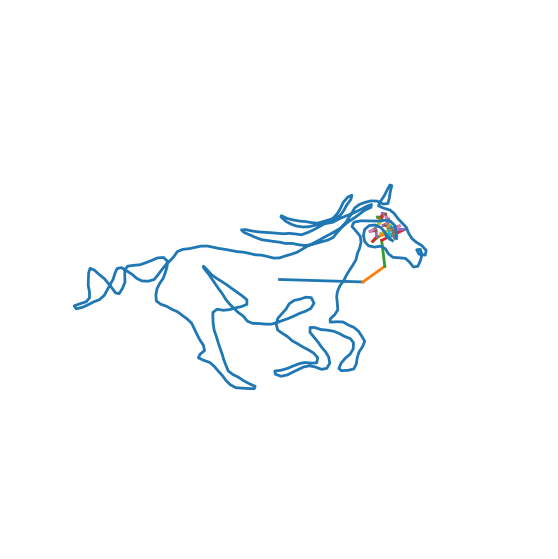

Saved GIF to: epicycles.gif


In [55]:

points = sample_svg("test_svg.svg", num_samples=2000)
freqs, coeffs = fourier_components(points)
anim = animate_epicycles(points, freqs, coeffs, n_vectors=250, frames=len(points), gif_seconds=8)
print("Saved GIF to: epicycles.gif")


## Top-K Error + Overlay

Top-250 max abs error:  5.541973e-03
Top-250 mean abs error: 1.818696e-03
Top-250 RMSE:           2.051792e-03


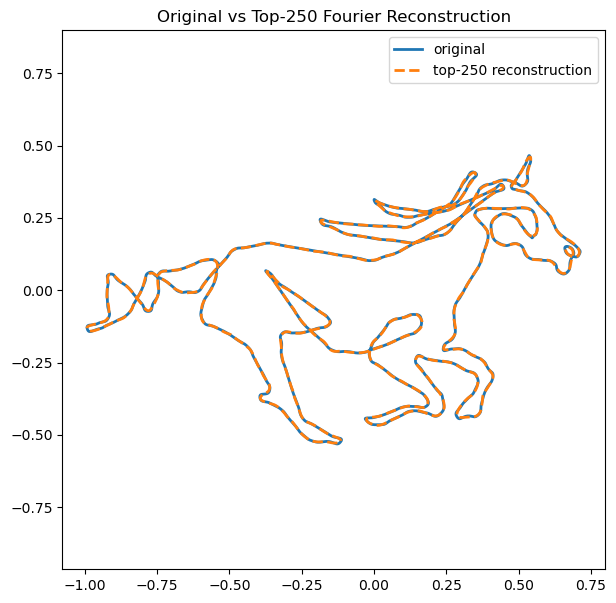

In [36]:
def reconstruct_topk(points, coeffs, n_vectors=250):
    z = points[:, 0] + 1j * points[:, 1]
    N = len(z)
    order = np.argsort(-np.abs(coeffs))[:n_vectors]

    coeffs_topk = np.zeros_like(coeffs)
    coeffs_topk[order] = coeffs[order]

    z_hat = np.fft.ifft(coeffs_topk * N)
    err = np.abs(z - z_hat)
    return z, z_hat, err


n_vectors = 250
z, z_hat, err = reconstruct_topk(points, coeffs, n_vectors=n_vectors)

print(f"Top-{n_vectors} max abs error:  {err.max():.6e}")
print(f"Top-{n_vectors} mean abs error: {err.mean():.6e}")
print(f"Top-{n_vectors} RMSE:           {np.sqrt(np.mean(err**2)):.6e}")

plt.figure(figsize=(7, 7))
plt.plot(z.real, z.imag, linewidth=2, label="original")
plt.plot(z_hat.real, z_hat.imag, "--", linewidth=2, label=f"top-{n_vectors} reconstruction")
plt.axis("equal")
plt.legend()
plt.title(f"Original vs Top-{n_vectors} Fourier Reconstruction")
plt.show()